In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

In [2]:
data = pd.read_csv("Data.csv", sep=";", decimal=",")
freitexte = pd.read_csv("freitexte.csv", sep=";")

print(data.shape)
print(freitexte.shape)

data.head()

(10000, 51)
(2524, 1)


,nachforderung,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49
0,0.00,2.0,0.00,20.466667,0.000000,327.0,0.0,0,0,1,...,0,0,0.0,0,0,0.0,0.0,0.0,0,0.92
1,19.98,3.0,0.00,78.868797,58.613585,353.0,0.0,0,0,1,...,0,0,0.0,0,0,0.0,0.0,0.0,0,6.77
2,0.00,2.0,0.00,0.000000,0.000000,0.0,0.0,0,0,0,...,0,0,0.0,0,0,0.0,0.0,0.0,0,0.04
3,0.00,2.0,0.00,0.000000,0.000000,0.0,0.0,0,0,1,...,0,0,0.0,0,0,0.0,0.0,0.0,0,1.93
4,0.00,8.0,4.05,248.197640,281.908553,3585.0,0.0,6,0,0,...,0,0,0.0,0,0,0.0,0.0,0.0,0,0.30


In [5]:

print(data.columns)

print(data.dtypes)

missing_values = data.isna().sum()
print(missing_values[missing_values > 0])

data.describe()

Index(['nachforderung', 'feature_0', 'feature_1', 'feature_2', 'feature_3',
       'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8',
       'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13',
       'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18',
       'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23',
       'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28',
       'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33',
       'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38',
       'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43',
       'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48',
       'feature_49'],
      dtype='str')
nachforderung    float64
feature_0        float64
feature_1        float64
feature_2        float64
feature_3        float64
feature_4        float64
feature_5        float64
feature_6          in

,nachforderung,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,424.715052,91.067076,-1.771072,170.830573,116.891288,1244.415159,0.114589,1.188200,0.068500,0.594600,...,0.037800,0.016500,0.016217,0.00990,0.009300,-2.906734,-0.104624,2.413466,0.00380,22.787845
std,5140.835421,2265.362919,242.750198,900.712165,291.536021,3914.342644,0.663316,2.084182,1.070571,0.494242,...,0.190722,0.127395,0.125043,0.09901,0.095992,88.985883,4.530248,27.599322,0.06153,232.865838
min,0.000000,0.000000,-20629.200000,-223.537228,-1528.390000,-1014.940000,-50.846305,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,-5033.620000,-279.458273,0.000000,0.00000,0.000000
25%,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.400000
50%,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,1.060000
75%,2.000000,27.000000,2.910000,181.620427,127.126256,1715.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,1.720000
max,311120.640000,180593.700000,2734.000000,63507.098330,8576.390000,296846.000000,2.000000,8.000000,33.000000,5.000000,...,1.000000,1.000000,1.000000,1.00000,1.000000,0.000000,70.016667,1369.470000,1.00000,8891.530000


In [3]:
print(data.columns)
print(data.dtypes)
print(data.isna().sum())

Index(['nachforderung', 'feature_0', 'feature_1', 'feature_2', 'feature_3',
       'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8',
       'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13',
       'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18',
       'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23',
       'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28',
       'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33',
       'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38',
       'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43',
       'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48',
       'feature_49'],
      dtype='str')
nachforderung    float64
feature_0        float64
feature_1        float64
feature_2        float64
feature_3        float64
feature_4        float64
feature_5        float64
feature_6          in

In [4]:
y = data["nachforderung"]

print("Anzahl Betriebe:", len(y))
print("Nachforderung > 0:", (y > 0).sum())
print("Nachforderung = 0:", (y == 0).sum())
print("Mittelwert:", y.mean())
print("Median:", y.median())
print("Maximum:", y.max())

print(y.quantile([0.5, 0.75, 0.9, 0.95, 0.99]))

Anzahl Betriebe: 10000
Nachforderung > 0: 2524
Nachforderung = 0: 7476
Mittelwert: 424.71505200000007
Median: 0.0
Maximum: 311120.64
0.50       0.0000
0.75       2.0000
0.90     176.2390
0.95     733.1685
0.99    7147.1187
Name: nachforderung, dtype: float64


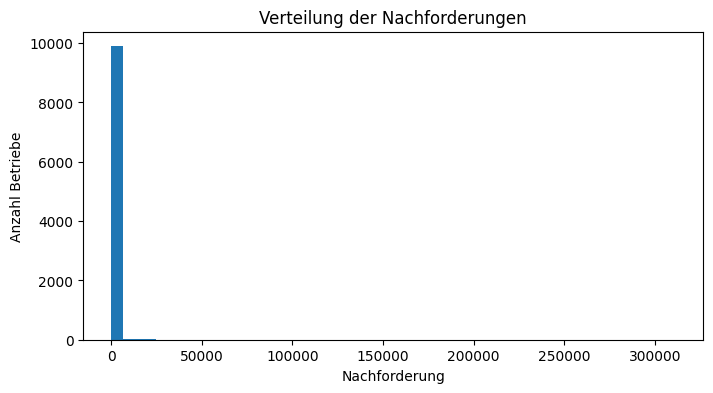

In [7]:

plt.figure(figsize=(8, 4))
plt.hist(y, bins=50)
plt.title("Verteilung der Nachforderungen")
plt.xlabel("Nachforderung")
plt.ylabel("Anzahl Betriebe")
plt.show()

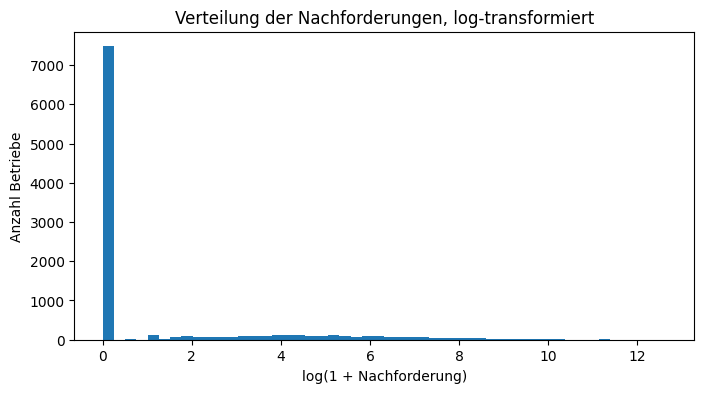

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(y), bins=50)
plt.title("Verteilung der Nachforderungen, log-transformiert")
plt.xlabel("log(1 + Nachforderung)")
plt.ylabel("Anzahl Betriebe")
plt.show()

In [10]:

X = data.drop(columns=["nachforderung"])
y = data["nachforderung"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Baseline: immer Mittelwert des Trainingssets vorhersagen
baseline_prediction = np.repeat(y_train.mean(), len(y_test))

mae_baseline = mean_absolute_error(y_test, baseline_prediction)
rmse_baseline = mean_squared_error(y_test, baseline_prediction) ** 0.5

print("Baseline MAE:", mae_baseline)
print("Baseline RMSE:", rmse_baseline)

Baseline MAE: 715.9653182400001
Baseline RMSE: 3172.2763367927187


In [11]:
#viele betrieve haben 0 nachforderung so wir koennen das auch als baseline testen

zero_prediction = np.repeat(0, len(y_test))

mae_zero = mean_absolute_error(y_test, zero_prediction)
rmse_zero = mean_squared_error(y_test, zero_prediction) ** 0.5

print("Zero Baseline MAE:", mae_zero)
print("Zero Baseline RMSE:", rmse_zero)

Zero Baseline MAE: 367.43302
Zero Baseline RMSE: 3192.6818284049073


In [ ]:
# die 0 baseline ist besser bei MAE weil fast 3/4 der Betriebe 0 nachforderung haben so 0 vorherzusagen ist fast immer richtig
#(natuerlich reicht das nicht aus weil wenn es einen betrieb mit einer nachforderung von 10k oder 50k oder sowas auch 0 sagen wuerde
# Wir muessen pruefen ob es ueberhaupt betriebe mit nachforderungen erkennt und ob es hohe nachforderungen kann

In [13]:

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_depth=8
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = mean_squared_error(y_test, rf_pred) ** 0.5

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 103.17138159612679
Random Forest RMSE: 1152.4858884676162


In [14]:
positive_test_mask = y_test > 0

mae_rf_positive = mean_absolute_error(
    y_test[positive_test_mask],
    rf_pred[positive_test_mask]
)

mae_zero_positive = mean_absolute_error(
    y_test[positive_test_mask],
    zero_prediction[positive_test_mask]
)

print("Random Forest MAE positive Fälle:", mae_rf_positive)
print("Zero Baseline MAE positive Fälle:", mae_zero_positive)

Random Forest MAE positive Fälle: 411.45011127293435
Zero Baseline MAE positive Fälle: 1530.9709166666667


In [ ]:
#viel besser als 0 baseline

In [15]:
results = pd.DataFrame({
    "y_true": y_test,
    "y_pred": rf_pred,
    "abs_error": abs(y_test - rf_pred)
})

results.sort_values("abs_error", ascending=False).head(20)

,y_true,y_pred,abs_error
5090,23219.97,52991.313452,29771.343452
1446,73311.48,46945.921899,26365.558101
3125,43952.62,25779.763368,18172.856632
8930,4367.14,18795.374570,14428.234570
5332,15135.76,25000.973145,9865.213145
2742,10816.84,19441.517246,8624.677246
1825,20038.69,28206.732860,8168.042860
4084,3675.51,11077.243019,7401.733019
7792,27160.20,20293.652383,6866.547617
8264,2478.58,8722.754954,6244.174954


In [16]:
print("Durchschnittlicher Fehler:", results["abs_error"].mean())
print("Median Fehler:", results["abs_error"].median())
print("95%-Quantil Fehler:", results["abs_error"].quantile(0.95))
print("99%-Quantil Fehler:", results["abs_error"].quantile(0.99))
print("Maximaler Fehler:", results["abs_error"].max())

Durchschnittlicher Fehler: 103.17138159612679
Median Fehler: 2.7899616258522464
95%-Quantil Fehler: 66.94520644034603
99%-Quantil Fehler: 1519.090062934768
Maximaler Fehler: 29771.343451890345


In [ ]:
#bei ausreiser mit hohen nachforderungen ist es ziemlich schlecht

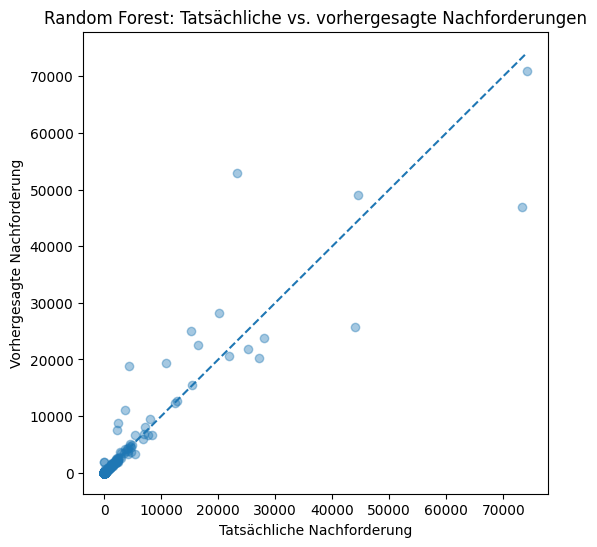

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_pred, alpha=0.4)

max_value = max(y_test.max(), rf_pred.max())
plt.plot([0, max_value], [0, max_value], linestyle="--")

plt.xlabel("Tatsächliche Nachforderung")
plt.ylabel("Vorhergesagte Nachforderung")
plt.title("Random Forest: Tatsächliche vs. vorhergesagte Nachforderungen")
plt.show()

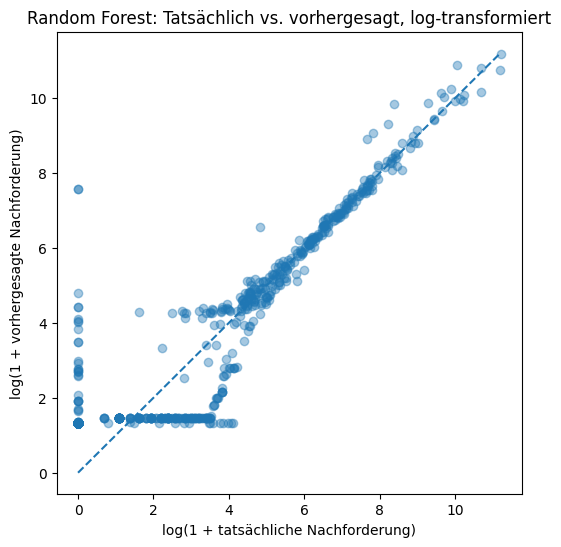

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(np.log1p(y_test), np.log1p(rf_pred), alpha=0.4)

max_value = max(np.log1p(y_test).max(), np.log1p(rf_pred).max())
plt.plot([0, max_value], [0, max_value], linestyle="--")

plt.xlabel("log(1 + tatsächliche Nachforderung)")
plt.ylabel("log(1 + vorhergesagte Nachforderung)")
plt.title("Random Forest: Tatsächlich vs. vorhergesagt, log-transformiert")
plt.show()

In [19]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
49,feature_49,0.579819
0,feature_0,0.214457
7,feature_7,0.050238
23,feature_23,0.025534
4,feature_4,0.023931
1,feature_1,0.020547
33,feature_33,0.018775
18,feature_18,0.012881
6,feature_6,0.009562
26,feature_26,0.006750


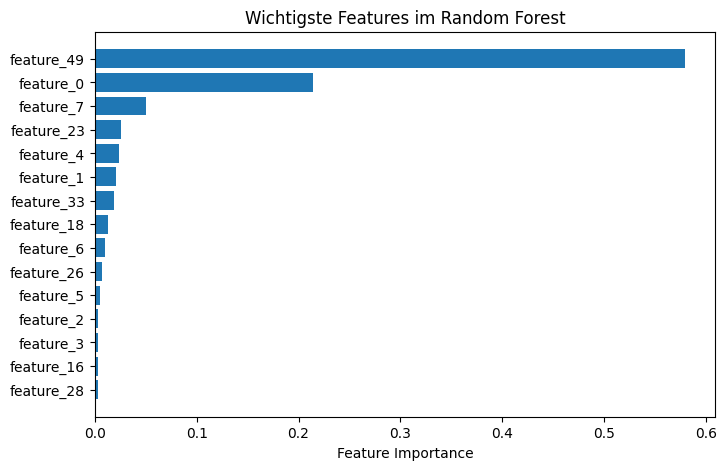

In [20]:
top_features = feature_importance.head(15)

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Wichtigste Features im Random Forest")
plt.show()

In [ ]:
#Permutation importance

In [21]:


perm_importance = permutation_importance(
    rf,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

perm_df = perm_df.sort_values("importance_mean", ascending=False)

perm_df.head(15)

,feature,importance_mean,importance_std
49,feature_49,684.135182,54.445318
0,feature_0,266.983692,36.744381
4,feature_4,8.143630,5.967266
1,feature_1,3.711294,3.784479
2,feature_2,0.910102,0.603665
16,feature_16,0.906141,0.310322
8,feature_8,0.901743,0.547424
3,feature_3,0.781466,0.632435
40,feature_40,0.647635,1.465474
19,feature_19,0.589300,0.654013


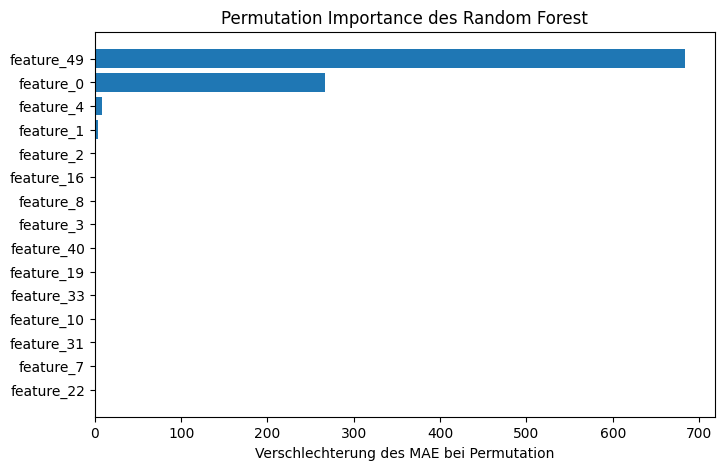

In [22]:
top_perm = perm_df.head(15)

plt.figure(figsize=(8, 5))
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("Verschlechterung des MAE bei Permutation")
plt.title("Permutation Importance des Random Forest")
plt.show()